# Import Libraries

In [ ]:
import math
import itertools
from typing import List, Dict, Tuple, Any, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

# Load Dataset and Split Seasons

In [ ]:
dataset2_path = "/content/drive/MyDrive/BAT RAT DATASET/dataset2_with_rat_eating.csv"
df2 = pd.read_csv(dataset2_path)

# Display columns and shape
print("Columns in dataset2:", df2.columns)
print("Dataset2 shape:", df2.shape)

# Split by month or season
if 'month' in df2.columns:
    df2_winter = df2[df2['month'].isin([0, 1, 2])]
    df2_spring = df2[df2['month'].isin([3, 4, 5, 6])]
elif 'season' in df2.columns:
    df2_winter = df2[df2['season'].str.lower() == 'winter']
    df2_spring = df2[df2['season'].str.lower() == 'spring']
else:
    raise ValueError("Dataset2 must contain either a 'month' or 'season' column for splitting.")

# Save seasonal CSVs
winter_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/winter_dataset2_with_rat_eating.csv"
spring_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/spring_dataset2_with_rat_eating.csv"
df2_winter.to_csv(winter_csv_path, index=False)
df2_spring.to_csv(spring_csv_path, index=False)

print("Winter dataset2 shape:", df2_winter.shape)
print("Spring dataset2 shape:", df2_spring.shape)

Columns in dataset2: Index(['time', 'month', 'hours_after_sunset', 'bat_landing_number',
       'food_availability', 'rat_minutes', 'rat_arrival_number', 'rat_eating'],
      dtype='object')
Dataset2 shape: (2123, 8)
Winter dataset2 shape: (880, 8)
Spring dataset2 shape: (1243, 8)


#Define Candidate Predictors and Response

In [ ]:
response_var = "bat_landing_number"

# Initial candidate predictors from full dataset
candidate_predictors_all = ['food_availability', 'rat_minutes', 'rat_arrival_number', 'rat_eating']

print("Response variable:", response_var)
print("Candidate predictors:", candidate_predictors_all)

Response variable: bat_landing_number
Candidate predictors: ['food_availability', 'rat_minutes', 'rat_arrival_number', 'rat_eating']


#Define Utility Functions for Model Selection

In [ ]:

def _fit_and_score(X_train, X_test, y_train, y_test, predictors):
    lm = LinearRegression()
    lm.fit(X_train[predictors], y_train)

    yhat_test = lm.predict(X_test[predictors])
    yhat_train = lm.predict(X_train[predictors])

    r2_test = r2_score(y_test, yhat_test)
    r2_train = r2_score(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    mae_test = mean_absolute_error(y_test, yhat_test)
    rmse_test = math.sqrt(mse_test)

    # statsmodels for adjusted R^2 on train
    Xsm = sm.add_constant(X_train[predictors], has_constant="add")
    sm_model = sm.OLS(y_train, Xsm).fit()
    adj_r2_train = sm_model.rsquared_adj

    return {
        "predictors": predictors[:],
        "n_features": len(predictors),
        "r2_test": r2_test,
        "r2_train": r2_train,
        "adj_r2_train": adj_r2_train,
        "mse_test": mse_test,
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "sm_summary": sm_model.summary(),
    }

def _all_subsets(features, min_k=1, max_k=None):
    if max_k is None:
        max_k = len(features)
    for r in range(min_k, max_k+1):
        for combo in itertools.combinations(features, r):
            yield list(combo)

def select_best_predictors_by_test_r2(dataset_path, response_var, candidate_predictors, test_size=0.4, random_state=42):
    df = pd.read_csv(dataset_path)
    X = df[candidate_predictors]
    y = df[response_var]
    data = pd.concat([X, y], axis=1).dropna()
    X = data[candidate_predictors]
    y = data[response_var]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    results = []
    for subset in _all_subsets(candidate_predictors):
        res = _fit_and_score(X_train, X_test, y_train, y_test, subset)
        results.append({
            "predictors": ", ".join(res["predictors"]),
            "n_features": res["n_features"],
            "r2_test": res["r2_test"],
            "r2_train": res["r2_train"],
            "adj_r2_train": res["adj_r2_train"],
            "mse_test": res["mse_test"],
            "rmse_test": res["rmse_test"],
            "mae_test": res["mae_test"],
        })

    ranking = pd.DataFrame(results).sort_values(["r2_test", "adj_r2_train"], ascending=[False, False]).reset_index(drop=True)
    best_list = [c.strip() for c in ranking.loc[0, "predictors"].split(",")] if not ranking.empty else []

    return best_list, ranking

def print_ranking_table(ranking_df, top_n=5):
    display_df = ranking_df.copy()
    if top_n:
        display_df = display_df.head(top_n)
    for col in ["r2_test", "r2_train", "adj_r2_train", "mse_test", "rmse_test", "mae_test"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    print("\n===== Model Subset Ranking (sorted by best test R²) =====")
    print(display_df.to_string(index=False))

#Define Linear Regression Workflow

In [ ]:
def run_linear_workflow(data, response_var, predictor_vars, test_size=0.4, random_state=42, clip_negative_preds=True, show_plots=True):
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()
    X = df[predictor_vars]
    y = df[response_var]
    data_clean = pd.concat([X, y], axis=1).dropna()
    X_clean = data_clean[predictor_vars]
    y_clean = data_clean[response_var]

    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=test_size, random_state=random_state)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if clip_negative_preds:
        y_pred = np.where(y_pred < 0, 0, y_pred)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    nrmse = rmse / (y_test.max() - y_test.min())

    # Statsmodels OLS
    x_with_const = sm.add_constant(X_clean)
    ols_model = sm.OLS(y_clean, x_with_const).fit()

    # VIF
    X_with_const = sm.add_constant(X_clean)
    vif_rows = []
    for i in range(X_with_const.shape[1]):
        if X_with_const.columns[i] == "const":
            continue
        vif_rows.append({"Variable": X_with_const.columns[i], "VIF": variance_inflation_factor(X_with_const.values, i)})
    vif_df = pd.DataFrame(vif_rows)

    if show_plots:
        # Actual vs Predicted
        plt.figure(figsize=(8,6))
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
        plt.xlabel(f"Actual {response_var}")
        plt.ylabel(f"Predicted {response_var}")
        plt.title("Actual vs Predicted")
        plt.show()

    return {
        "df": df,
        "data_clean": data_clean,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "model": model,
        "ols_model": ols_model,
        "metrics": {"r2_test": r2, "mse_test": mse, "mae_test": mae, "rmse_test": rmse, "nrmse_test": nrmse},
        "vif": vif_df
    }

#Winter Linear Regression

In [ ]:
def get_valid_predictors(df, candidate_predictors):
    """
    Return only the predictors that exist as columns in the dataframe.
    """
    return [col for col in candidate_predictors if col in df.columns]


Running Linear Regression for WINTER dataset
Winter valid predictors: ['rat_minutes', 'food_availability', 'rat_eating', 'rat_arrival_number']

===== Model Subset Ranking (sorted by best test R²) =====
                                                    predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
rat_minutes, food_availability, rat_eating, rat_arrival_number           4   0.0554    0.0415        0.0342  573.9554    23.9574   19.3696
                    rat_minutes, food_availability, rat_eating           3   0.0544    0.0348        0.0293  574.5513    23.9698   19.3865
            rat_minutes, food_availability, rat_arrival_number           3   0.0418    0.0381        0.0326  582.2021    24.1289   19.5673
                   rat_minutes, rat_eating, rat_arrival_number           3   0.0398    0.0308        0.0252  583.3986    24.1536   19.6628
                                       rat_minutes, rat_eating           2   0.0396    0.0235        0.

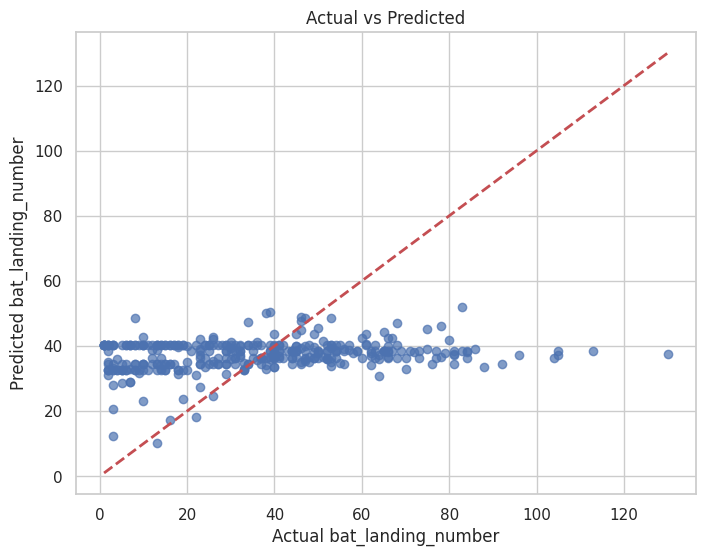

In [ ]:
print("Running Linear Regression for WINTER dataset")

# Load the Winter dataset
df2_winter = pd.read_csv("/content/drive/MyDrive/BAT RAT DATASET/winter_dataset2_with_rat_eating.csv")

# Candidate predictors (all possible)
candidate_predictors_all = [
    'seconds_after_rat_arrival', 'risk', 'reward',
    'rat_minutes', 'food_availability', 'rat_eating',
    'rat_arrival_number', 'rat_presence_duration_sec'
]

# Get only valid predictors for winter
candidate_predictors_winter = get_valid_predictors(df2_winter, candidate_predictors_all)
print("Winter valid predictors:", candidate_predictors_winter)

# Select best subset using existing function
best_predictors_winter, ranking_winter = select_best_predictors_by_test_r2(
    "/content/drive/MyDrive/BAT RAT DATASET/winter_dataset2_with_rat_eating.csv",
    response_var,
    candidate_predictors_winter,
    test_size=0.40,
    random_state=42
)

print_ranking_table(ranking_winter, top_n=5)

# Run Linear Regression workflow
results_winter = run_linear_workflow(
    data="/content/drive/MyDrive/BAT RAT DATASET/winter_dataset2_with_rat_eating.csv",
    response_var=response_var,
    predictor_vars=best_predictors_winter,
    test_size=0.40,
    random_state=42,
    clip_negative_preds=True,
    show_plots=True
)

#Spring Linear Regression

Running Linear Regression for SPRING dataset
Spring valid predictors: ['rat_minutes', 'food_availability', 'rat_eating', 'rat_arrival_number']

===== Model Subset Ranking (sorted by best test R²) =====
                                                    predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
            rat_minutes, food_availability, rat_arrival_number           3   0.0218    0.0296        0.0257  584.6503    24.1795   18.6785
                    rat_minutes, food_availability, rat_eating           3   0.0213    0.0278        0.0239  584.9618    24.1860   18.6818
                                rat_minutes, food_availability           2   0.0210    0.0278        0.0252  585.1159    24.1892   18.6870
rat_minutes, food_availability, rat_eating, rat_arrival_number           4   0.0210    0.0304        0.0252  585.1208    24.1893   18.7194
                         food_availability, rat_arrival_number           2   0.0155    0.0241        0.

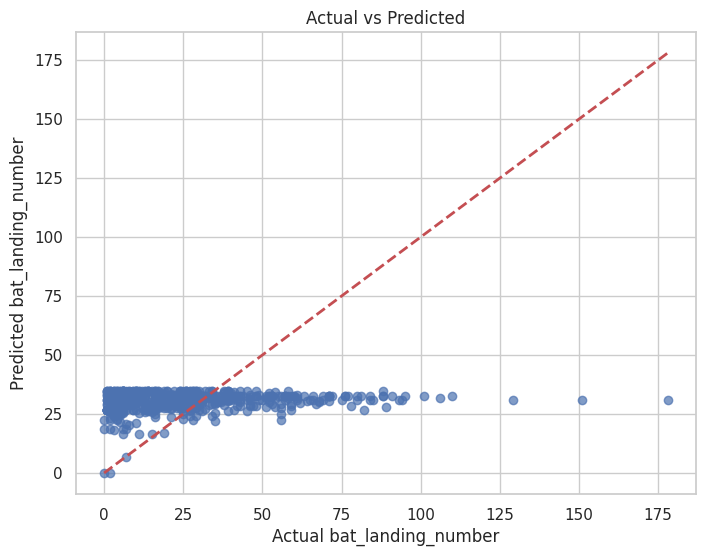

In [ ]:
print("Running Linear Regression for SPRING dataset")

# Load the Spring dataset
df2_spring = pd.read_csv("/content/drive/MyDrive/BAT RAT DATASET/spring_dataset2_with_rat_eating.csv")

# Candidate predictors (all possible)
candidate_predictors_all = [
    'seconds_after_rat_arrival', 'risk', 'reward',
    'rat_minutes', 'food_availability', 'rat_eating',
    'rat_arrival_number', 'rat_presence_duration_sec'
]

# Get only valid predictors for spring
candidate_predictors_spring = get_valid_predictors(df2_spring, candidate_predictors_all)
print("Spring valid predictors:", candidate_predictors_spring)

# Select best subset based on test R²
best_predictors_spring, ranking_spring = select_best_predictors_by_test_r2(
    "/content/drive/MyDrive/BAT RAT DATASET/spring_dataset2_with_rat_eating.csv",
    response_var,
    candidate_predictors_spring,
    test_size=0.40,
    random_state=42
)

print_ranking_table(ranking_spring, top_n=5)

# Run Linear Regression workflow
results_spring = run_linear_workflow(
    data="/content/drive/MyDrive/BAT RAT DATASET/spring_dataset2_with_rat_eating.csv",
    response_var=response_var,
    predictor_vars=best_predictors_spring,
    test_size=0.40,
    random_state=42,
    clip_negative_preds=True,
    show_plots=True
)

#Compare Winter and Spring Linear Regression

In [ ]:
print("\n============================")
print("Comparing Winter and Spring Linear Regression Models")
print("============================")

# Collect metrics
metrics_comparison = pd.DataFrame({
    "Season": ["Winter", "Spring"],
    "R2_test": [results_winter['metrics']['r2_test'], results_spring['metrics']['r2_test']],
    "MSE_test": [results_winter['metrics']['mse_test'], results_spring['metrics']['mse_test']],
    "MAE_test": [results_winter['metrics']['mae_test'], results_spring['metrics']['mae_test']],
    "RMSE_test": [results_winter['metrics']['rmse_test'], results_spring['metrics']['rmse_test']]
})

print(metrics_comparison)

# Compare coefficients
coef_comparison = pd.DataFrame({
    "Predictor": best_predictors_winter + best_predictors_spring,
    "Coefficient": list(results_winter['model'].coef_) + list(results_spring['model'].coef_),
    "Season": ["Winter"] * len(best_predictors_winter) + ["Spring"] * len(best_predictors_spring)
})
print("\nCoefficient comparison:")
print(coef_comparison)


Comparing Winter and Spring Linear Regression Models
   Season   R2_test    MSE_test   MAE_test  RMSE_test
0  Winter  0.055390  573.955387  19.369559  23.957366
1  Spring  0.022843  584.026517  18.632189  24.166641

Coefficient comparison:
            Predictor  Coefficient  Season
0         rat_minutes    -2.611031  Winter
1   food_availability     1.939992  Winter
2          rat_eating     6.737367  Winter
3  rat_arrival_number     2.353351  Winter
4         rat_minutes    -0.313072  Spring
5   food_availability     1.936475  Spring
6  rat_arrival_number    -1.364327  Spring


#Visualization of Winter vs Spring (Dataset2)

/tmp/ipython-input-2973995508.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


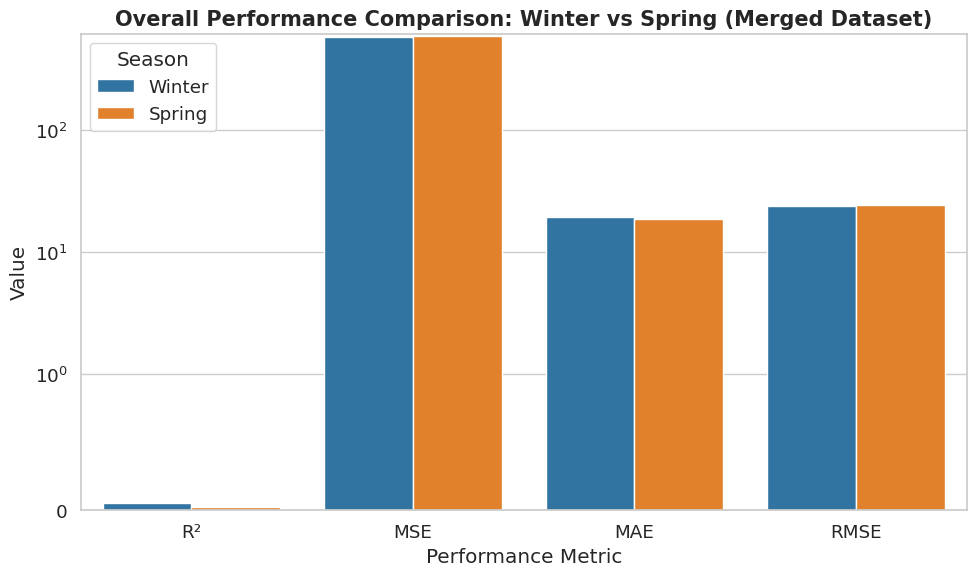

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Updated comparison dataframe based on latest results
comparison_df = pd.DataFrame({
    "Metric": ["R²", "MSE", "MAE", "RMSE"],
    "Winter": [0.055390, 573.955387, 19.369559, 23.957366],
    "Spring": [0.022843, 584.026517, 18.632189, 24.166641]
})

# Melt for seaborn
comparison_melted = comparison_df.melt(id_vars="Metric", var_name="Season", value_name="Value")

# Set plot style
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Define colors
colors = ["#1f77b4", "#ff7f0e"]

# Plot bars
ax = sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Value",
    hue="Season",
    palette=colors,
    dodge=True,
    ci=None
)

# Use symlog scale for metrics with large values
ax.set_yscale("symlog", linthresh=1)

ax.set_ylabel("Value")
ax.set_xlabel("Performance Metric")
plt.title("Overall Performance Comparison: Winter vs Spring (Merged Dataset)", fontsize=15, weight="bold")
plt.legend(title="Season", loc="upper left")

plt.tight_layout()
plt.show()


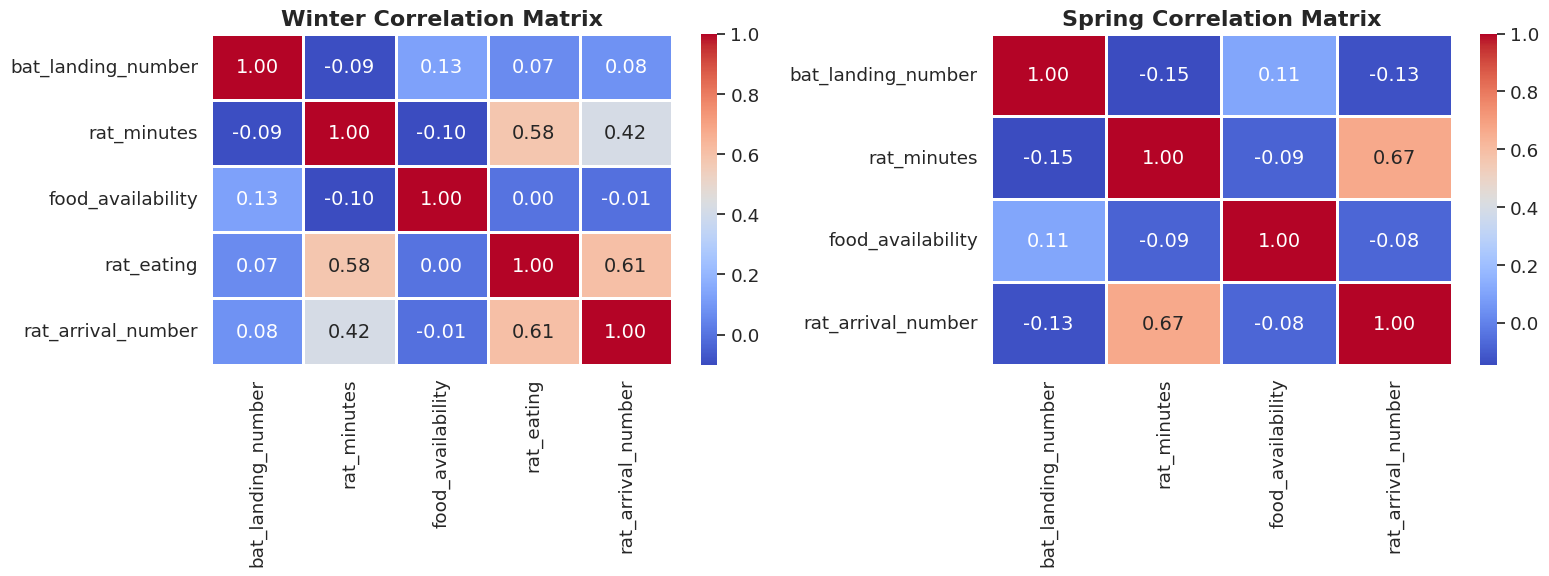

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Columns of interest: response + valid predictors for Winter and Spring
cols_winter = [response_var] + best_predictors_winter
cols_spring = [response_var] + best_predictors_spring

# Select only numeric columns for correlation
numeric_winter = df2_winter[cols_winter].select_dtypes(include=["float64", "int64"])
numeric_spring = df2_spring[cols_spring].select_dtypes(include=["float64", "int64"])

# Compute correlation matrices
corr_winter = numeric_winter.corr()
corr_spring = numeric_spring.corr()

# Create side-by-side plots with bigger figure for clearer cubes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # larger figure

# --- Winter ---
sns.heatmap(
    corr_winter, annot=True, fmt=".2f", cmap="coolwarm",
    cbar=True, linewidths=1.0, ax=axes[0],
    annot_kws={"size": 14}  # bigger font
)
axes[0].set_title("Winter Correlation Matrix", fontsize=16, fontweight="bold")

# --- Spring ---
sns.heatmap(
    corr_spring, annot=True, fmt=".2f", cmap="coolwarm",
    cbar=True, linewidths=1.0, ax=axes[1],
    annot_kws={"size": 14}  # bigger font
)
axes[1].set_title("Spring Correlation Matrix", fontsize=16, fontweight="bold")

# Adjust layout for readability
plt.tight_layout()
plt.show()
